# Experimento Final: Fusión Multimodal Propuesta
**Arquitectura de la tesis (Sección III) — fusión intermedia diferenciable end-to-end**

A diferencia de la concatenación simple, esta propuesta:
1. **Rama DINOv2** (geométrica) → proyección a espacio latente
2. **Rama CLIP** (semántica) → proyección a espacio latente
3. **Rama MLP clínica** → procesa metadata con no-linealidades (ec. 5 de la tesis)
4. **Fusión intermedia** → concatenación de las 3 proyecciones (ec. 6)
5. **Clasificador** → capa lineal + sigmoide (ec. 7), optimizado end-to-end con BCE regularizada (ec. 8)

Backbones congelados (∇θ=0) — solo se entrenan Θ = {proyecciones, θ_mlp, Wc, bc}

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

Dispositivo: cuda
GPU: Tesla T4


## 1. Cargar embeddings y labels

In [3]:
BASE_PATH    = '/content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20'
RESULTS_PATH = os.path.join(BASE_PATH, 'resultados')

# Embeddings visuales (ya extraídos y guardados)
clip_train = np.load(os.path.join(RESULTS_PATH, 'clip_X_train.npy'))
clip_val   = np.load(os.path.join(RESULTS_PATH, 'clip_X_val.npy'))
clip_test  = np.load(os.path.join(RESULTS_PATH, 'clip_X_test.npy'))

dino_train = np.load(os.path.join(RESULTS_PATH, 'dino_X_train.npy'))
dino_val   = np.load(os.path.join(RESULTS_PATH, 'dino_X_val.npy'))
dino_test  = np.load(os.path.join(RESULTS_PATH, 'dino_X_test.npy'))

y_train = np.load(os.path.join(RESULTS_PATH, 'y_train.npy'))
y_val   = np.load(os.path.join(RESULTS_PATH, 'y_val.npy'))
y_test  = np.load(os.path.join(RESULTS_PATH, 'y_test.npy'))

print(f'CLIP: {clip_train.shape} | DINOv2: {dino_train.shape} | Labels: {y_train.shape}')

CLIP: (1838, 768) | DINOv2: (1838, 1024) | Labels: (1838,)


## 2. Preprocesar metadata clínica

In [4]:
df_train = pd.read_csv(os.path.join(BASE_PATH, 'split_train.csv'))
df_val   = pd.read_csv(os.path.join(BASE_PATH, 'split_val.csv'))
df_test  = pd.read_csv(os.path.join(BASE_PATH, 'split_test.csv'))

META_COLS = [
    'smoke', 'drink', 'pesticide', 'gender',
    'skin_cancer_history', 'cancer_history',
    'has_piped_water', 'has_sewage_system',
    'age', 'fitspatrick', 'diameter_1', 'diameter_2',
    'region', 'background_father', 'background_mother',
    'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation'
]
NUM_COLS = ['age', 'fitspatrick', 'diameter_1', 'diameter_2']
CAT_COLS = [c for c in META_COLS if c not in NUM_COLS]

def preprocess_metadata(df_train, df_val, df_test, meta_cols, num_cols, cat_cols):
    tr = df_train[meta_cols].copy()
    va = df_val[meta_cols].copy()
    te = df_test[meta_cols].copy()
    scaler = MinMaxScaler()
    tr[num_cols] = scaler.fit_transform(tr[num_cols])
    va[num_cols] = scaler.transform(va[num_cols])
    te[num_cols] = scaler.transform(te[num_cols])
    for df in [tr, va, te]:
        for col in df.select_dtypes(include='bool').columns:
            df[col] = df[col].astype(int)
    string_cats = [c for c in cat_cols if tr[c].dtype == object]
    tr_enc = pd.get_dummies(tr, columns=string_cats)
    va_enc = pd.get_dummies(va, columns=string_cats)
    te_enc = pd.get_dummies(te, columns=string_cats)
    va_enc = va_enc.reindex(columns=tr_enc.columns, fill_value=0)
    te_enc = te_enc.reindex(columns=tr_enc.columns, fill_value=0)
    return tr_enc.values.astype(np.float32), va_enc.values.astype(np.float32), te_enc.values.astype(np.float32)

M_train, M_val, M_test = preprocess_metadata(df_train, df_val, df_test, META_COLS, NUM_COLS, CAT_COLS)
print(f'Metadata: {M_train.shape}')

Metadata: (1838, 69)


## 3. DataLoaders (3 modalidades separadas)

In [5]:
# Mantenemos las modalidades SEPARADAS (no concatenadas) porque
# la fusión ocurre DENTRO del modelo (fusión intermedia)
def make_loader(clip_x, dino_x, meta_x, y, batch_size=64, shuffle=False):
    ds = TensorDataset(
        torch.tensor(clip_x, dtype=torch.float32),
        torch.tensor(dino_x, dtype=torch.float32),
        torch.tensor(meta_x, dtype=torch.float32),
        torch.tensor(y,      dtype=torch.float32)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(clip_train, dino_train, M_train, y_train, shuffle=True)
val_loader   = make_loader(clip_val,   dino_val,   M_val,   y_val,   shuffle=False)
test_loader  = make_loader(clip_test,  dino_test,  M_test,  y_test,  shuffle=False)

print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Batches — Train: 29 | Val: 4 | Test: 4


## 4. Arquitectura de Fusión Intermedia Propuesta
Cada modalidad se proyecta a un espacio latente común antes de fusionar.

In [6]:
class FusionMultimodal(nn.Module):
    """
    Arquitectura de fusión intermedia diferenciable de la tesis.

    - Rama DINOv2 (geométrica):  proyección 1024 -> proj_dim
    - Rama CLIP (semántica):     proyección 768  -> proj_dim
    - Rama MLP clínica:          metadata -> proj_dim (con no-linealidades, ec. 5)
    - Fusión intermedia:         concatenación de las 3 proyecciones (ec. 6)
    - Clasificador:              capa lineal + sigmoide (ec. 7)
    """
    def __init__(self, clip_dim=768, dino_dim=1024, meta_dim=None, proj_dim=256, dropout=0.3):
        super().__init__()

        # Rama DINOv2 — proyección del descriptor geométrico
        self.dino_proj = nn.Sequential(
            nn.Linear(dino_dim, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Rama CLIP — proyección del anclaje semántico
        self.clip_proj = nn.Sequential(
            nn.Linear(clip_dim, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Rama MLP clínica — f_clin = ReLU(W2 · ReLU(W1·x + b1) + b2)  [ec. 5]
        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, proj_dim),
            nn.ReLU()
        )

        # Clasificador sobre el vector fusionado z_fused (ec. 7)
        fused_dim = proj_dim * 3
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self, x_clip, x_dino, x_meta):
        f_dino = self.dino_proj(x_dino)   # rama geométrica
        f_clip = self.clip_proj(x_clip)   # rama semántica
        f_clin = self.meta_mlp(x_meta)    # rama clínica

        # Fusión intermedia: z_fused = f_dino ∥ f_clip ∥ f_clin  (ec. 6)
        z_fused = torch.cat([f_dino, f_clip, f_clin], dim=1)

        logits = self.classifier(z_fused).squeeze(1)  # (ec. 7)
        return logits

meta_dim = M_train.shape[1]
model = FusionMultimodal(clip_dim=768, dino_dim=1024, meta_dim=meta_dim, proj_dim=256).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Metadata dim: {meta_dim}')
print(f'Parámetros entrenables: {trainable:,}')
print(model)

Metadata dim: 69
Parámetros entrenables: 698,369
FusionMultimodal(
  (dino_proj): Sequential(
    (0): Linear(in_features=1024, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (clip_proj): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (meta_mlp): Sequential(
    (0): Linear(in_features=69, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=256, bias=True)
    (4): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=1, bias=True)
  )
)


## 5. Entrenamiento end-to-end

In [7]:
EPOCHS    = 50
LR        = 1e-3
THRESHOLD = 0.5
PATIENCE  = 12
WEIGHT_DECAY = 1e-4   # regularización L2 (λ de la ec. 8)

criterion       = nn.BCEWithLogitsLoss()
optimizer       = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler       = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
best_val_auc    = 0
patience_count  = 0
best_model_path = os.path.join(RESULTS_PATH, 'fusion_propuesta_best.pt')
history         = {'train_loss': [], 'val_loss': [], 'val_auc': []}

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for x_clip, x_dino, x_meta, y_b in train_loader:
        x_clip, x_dino, x_meta, y_b = x_clip.to(device), x_dino.to(device), x_meta.to(device), y_b.to(device)
        optimizer.zero_grad()
        logits = model(x_clip, x_dino, x_meta)
        loss   = criterion(logits, y_b)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss, val_probs, val_labels = 0, [], []
    with torch.no_grad():
        for x_clip, x_dino, x_meta, y_b in val_loader:
            x_clip, x_dino, x_meta, y_b = x_clip.to(device), x_dino.to(device), x_meta.to(device), y_b.to(device)
            logits    = model(x_clip, x_dino, x_meta)
            val_loss += criterion(logits, y_b).item()
            val_probs.extend(torch.sigmoid(logits).cpu().numpy())
            val_labels.extend(y_b.cpu().numpy())
    val_loss /= len(val_loader)
    val_auc   = roc_auc_score(val_labels, val_probs)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    print(f'Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}')

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), best_model_path)
        patience_count = 0
        print(f' Mejor modelo (AUC={best_val_auc:.4f})')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'Early stopping epoch {epoch+1}')
            break

print(f'\nMejor Val AUC: {best_val_auc:.4f}')

Epoch 01 | Train Loss: 0.4543 | Val Loss: 0.2843 | Val AUC: 0.9544
 Mejor modelo (AUC=0.9544)
Epoch 02 | Train Loss: 0.2744 | Val Loss: 0.2651 | Val AUC: 0.9708
 Mejor modelo (AUC=0.9708)
Epoch 03 | Train Loss: 0.2379 | Val Loss: 0.2280 | Val AUC: 0.9705
Epoch 04 | Train Loss: 0.2155 | Val Loss: 0.2426 | Val AUC: 0.9668
Epoch 05 | Train Loss: 0.1831 | Val Loss: 0.2244 | Val AUC: 0.9686
Epoch 06 | Train Loss: 0.1681 | Val Loss: 0.2264 | Val AUC: 0.9679
Epoch 07 | Train Loss: 0.1506 | Val Loss: 0.2333 | Val AUC: 0.9673
Epoch 08 | Train Loss: 0.1387 | Val Loss: 0.2225 | Val AUC: 0.9675
Epoch 09 | Train Loss: 0.1218 | Val Loss: 0.2276 | Val AUC: 0.9667
Epoch 10 | Train Loss: 0.1145 | Val Loss: 0.2326 | Val AUC: 0.9693
Epoch 11 | Train Loss: 0.1028 | Val Loss: 0.2305 | Val AUC: 0.9655
Epoch 12 | Train Loss: 0.1006 | Val Loss: 0.2614 | Val AUC: 0.9686
Epoch 13 | Train Loss: 0.0833 | Val Loss: 0.2557 | Val AUC: 0.9660
Epoch 14 | Train Loss: 0.0696 | Val Loss: 0.2644 | Val AUC: 0.9690
Early st

## 6. Curvas de entrenamiento

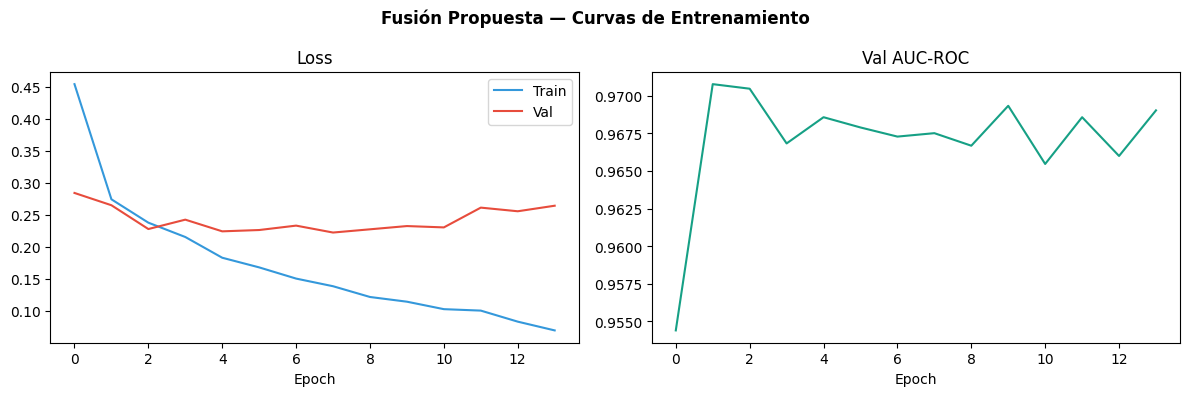

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train', color='#3498db')
axes[0].plot(history['val_loss'],   label='Val',   color='#e74c3c')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history['val_auc'], color='#16a085')
axes[1].set_title('Val AUC-ROC'); axes[1].set_xlabel('Epoch')
plt.suptitle('Fusión Propuesta — Curvas de Entrenamiento', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'fusion_propuesta_curvas.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluación en Test

In [9]:
model.load_state_dict(torch.load(best_model_path))
model.eval()

test_probs, test_labels = [], []
with torch.no_grad():
    for x_clip, x_dino, x_meta, y_b in test_loader:
        x_clip, x_dino, x_meta = x_clip.to(device), x_dino.to(device), x_meta.to(device)
        logits = model(x_clip, x_dino, x_meta)
        test_probs.extend(torch.sigmoid(logits).cpu().numpy())
        test_labels.extend(y_b.numpy())

test_probs  = np.array(test_probs)
test_labels = np.array(test_labels)
test_preds  = (test_probs >= THRESHOLD).astype(int)

auc       = roc_auc_score(test_labels, test_probs)
accuracy  = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds)
recall    = recall_score(test_labels, test_preds)
f1        = f1_score(test_labels, test_preds)

print('=' * 55)
print('  RESULTADOS — FUSIÓN MULTIMODAL PROPUESTA')
print('=' * 55)
print(f'  AUC-ROC   : {auc:.4f}')
print(f'  Accuracy  : {accuracy*100:.1f}%')
print(f'  Precision : {precision*100:.1f}%')
print(f'  Recall    : {recall*100:.1f}%')
print(f'  F1-Score  : {f1:.4f}')
print('=' * 55)
print()
print(classification_report(test_labels, test_preds, target_names=['Benigno', 'Maligno']))

  RESULTADOS — FUSIÓN MULTIMODAL PROPUESTA
  AUC-ROC   : 0.9571
  Accuracy  : 89.1%
  Precision : 87.6%
  Recall    : 90.0%
  F1-Score  : 0.8879

              precision    recall  f1-score   support

     Benigno       0.91      0.88      0.89       120
     Maligno       0.88      0.90      0.89       110

    accuracy                           0.89       230
   macro avg       0.89      0.89      0.89       230
weighted avg       0.89      0.89      0.89       230



## 8. Matriz de confusión

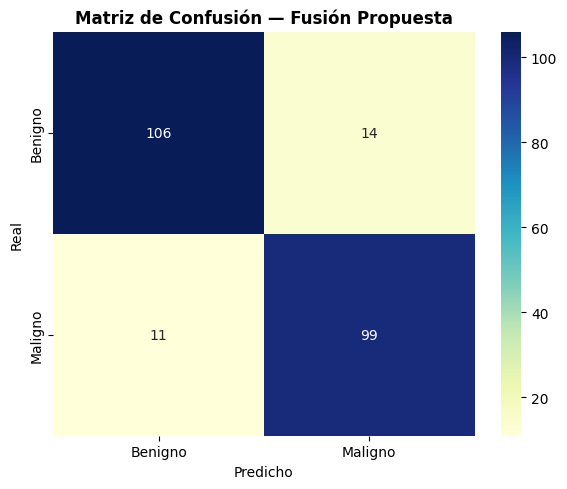

In [10]:
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Benigno', 'Maligno'],
            yticklabels=['Benigno', 'Maligno'], ax=ax)
ax.set_title('Matriz de Confusión — Fusión Propuesta', fontweight='bold')
ax.set_ylabel('Real'); ax.set_xlabel('Predicho')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'fusion_propuesta_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Guardar resultados

In [11]:
results = {
    'modelo':    'Fusión nueva (propuesta)',
    'backbone':  'CLIP + DINOv2 + MLP clínico (fusión intermedia)',
    'auc':       round(auc, 4),
    'accuracy':  round(accuracy, 4),
    'precision': round(precision, 4),
    'recall':    round(recall, 4),
    'f1':        round(f1, 4),
}
results_path = os.path.join(RESULTS_PATH, 'resultados_fusion_propuesta.csv')
pd.DataFrame([results]).to_csv(results_path, index=False)
print(f'Guardado en: {results_path}')
print(pd.DataFrame([results]))

Guardado en: /content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20/resultados/resultados_fusion_propuesta.csv
                     modelo                                         backbone  \
0  Fusión nueva (propuesta)  CLIP + DINOv2 + MLP clínico (fusión intermedia)   

      auc  accuracy  precision  recall      f1  
0  0.9571    0.8913     0.8761     0.9  0.8879  


## 10. Tabla comparativa final (todos los experimentos)

In [12]:
# Consolidar todos los resultados guardados
import glob

archivos = glob.glob(os.path.join(RESULTS_PATH, 'resultados_*.csv'))
dfs = [pd.read_csv(f) for f in archivos]
tabla_final = pd.concat(dfs, ignore_index=True)

# Ordenar por AUC
tabla_final = tabla_final.sort_values('auc', ascending=False).reset_index(drop=True)

print('=== TABLA COMPARATIVA FINAL (ordenada por AUC) ===\n')
cols_mostrar = ['modelo', 'auc', 'accuracy', 'precision', 'recall', 'f1']
print(tabla_final[cols_mostrar].to_string(index=False))

tabla_final[cols_mostrar].to_csv(os.path.join(RESULTS_PATH, 'TABLA_FINAL_consolidada.csv'), index=False)
print('\nTabla consolidada guardada')

=== TABLA COMPARATIVA FINAL (ordenada por AUC) ===

                     modelo    auc  accuracy  precision  recall     f1
              dino_metadata 0.9723    0.9174     0.9027  0.9273 0.9148
              clip_metadata 0.9692    0.9043     0.8729  0.9364 0.9035
CLIP+DINOv2+metadata limpia 0.9653    0.8870     0.8281  0.9636 0.8908
   Fusión nueva (propuesta) 0.9571    0.8913     0.8761  0.9000 0.8879
          convnext_metadata 0.9569    0.9087     0.9083  0.9000 0.9041
 CLIP+DINOv2 (sin metadata) 0.9098    0.8130     0.7557  0.9000 0.8216
         CLIP solo (imagen) 0.9048    0.8217     0.8053  0.8273 0.8161
              convnext_solo 0.8893    0.8087     0.8367  0.7455 0.7885
       DINOv2 solo (imagen) 0.8675    0.7783     0.7438  0.8182 0.7792

Tabla consolidada guardada
